# Assignment 01 — Part-of-Speech (POS) Extraction from a News Article

**Course:** AIAC 536 — Natural Language Processing
**Author:** Roshan Bharati
**Submission file:** `RoshanBharati_POS_01.ipynb`

---

## Objective
Apply NLP techniques to identify and extract **nouns** and **verbs** from an English news article.

## Pipeline
| Step | What happens |
|---|---|
| 1 | Load the article from a plain-text file |
| 2 | Clean the text (strip the source header, normalise whitespace) |
| 3 | Tokenise and POS-tag with **spaCy** (`en_core_web_sm`) |
| 4 | Cross-check the tagging with **NLTK**'s averaged perceptron tagger |
| 5 | Filter tokens down to nouns and verbs |
| 6 | Export to CSV as `RoshanBharati_POS_01.csv` |

## Source article
- **Headline:** *The real cause of most wildfires? People*
- **Publisher:** NPR (text edition)
- **URL:** <https://text.npr.org/nx-s1-5944328>
- **Retrieved:** 2026-08-28

The article is stored verbatim in `data/news_article.txt` for reproducibility.

## 1. Imports and configuration

In [1]:
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 40)

# Paths are relative to this notebook so the project stays portable.
ARTICLE_PATH = Path("data/news_article.txt")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH = OUTPUT_DIR / "RoshanBharati_POS_01.csv"
SUMMARY_PATH = OUTPUT_DIR / "RoshanBharati_POS_01_summary.csv"

print("spaCy:", spacy.__version__)
print("NLTK :", nltk.__version__)
print("pandas:", pd.__version__)

Matplotlib is building the font cache; this may take a moment.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/rosxnb/.local/share/uv/python/cpython-3.12.12-macos-x86_64-none/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/rosxnb/.local/share/uv/python/cpython-3.12.12-macos-x86_64-none/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/rosxnb/CodeHub/NLPSandbox/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/rosxnb/CodeHub/NLPSand

spaCy: 3.8.16
NLTK : 3.10.3
pandas: 3.0.5


## 2. Load the article

The `.txt` file carries a small provenance header (headline, source URL, retrieval date). That header is
metadata rather than article prose, so it is separated out before tagging — otherwise the URL would be
tokenised into dozens of meaningless "nouns".

In [2]:
raw_text = ARTICLE_PATH.read_text(encoding="utf-8")

print(f"Loaded {ARTICLE_PATH}")
print(f"Characters: {len(raw_text):,}")
print("\n--- first 400 characters ---\n")
print(raw_text[:400])

Loaded data/news_article.txt
Characters: 7,822

--- first 400 characters ---

The real cause of most wildfires? People

Source: NPR (text edition) - https://text.npr.org/nx-s1-5944328
Retrieved: 2026-08-28

The Hawk Fire that's been threatening Reno, Nevada is the latest destructive wildfire in the West in recent weeks that investigators believe was human-caused.

That moniker fits a larger pattern: Federal data show that more than three-quarters of all the wildfires in the


## 3. Clean the text\n\nSplit off the provenance header, then normalise whitespace and the typographic quotes/dashes NPR uses.

In [3]:
def split_header(text: str) -> tuple[str, str]:
    """Return (metadata_header, article_body).

    The header ends at the blank line following the 'Retrieved:' line.
    """
    marker = re.search(r"^Retrieved:.*$", text, flags=re.MULTILINE)
    if not marker:
        return "", text
    return text[: marker.end()], text[marker.end() :]


def normalise(text: str) -> str:
    """Fold typographic punctuation to ASCII and collapse runs of whitespace."""
    replacements = {
        "\u2018": "'", "\u2019": "'",     # curly single quotes
        "\u201c": '"', "\u201d": '"',     # curly double quotes
        "\u2014": " - ", "\u2013": " - ",  # em / en dash
        "\u00a0": " ",                    # non-breaking space
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


header, body = split_header(raw_text)
article_text = normalise(body)

print("--- metadata header (excluded from tagging) ---")
print(header)
print(f"\nArticle body: {len(article_text):,} characters, "
      f"{len(article_text.split()):,} whitespace tokens")

--- metadata header (excluded from tagging) ---
The real cause of most wildfires? People

Source: NPR (text edition) - https://text.npr.org/nx-s1-5944328
Retrieved: 2026-08-28

Article body: 7,692 characters, 1,238 whitespace tokens


## 4. POS tagging with spaCy

`en_core_web_sm` gives two tag layers for every token:

- **`token.pos_`** — the coarse [Universal POS tag](https://universaldependencies.org/u/pos/) (`NOUN`, `VERB`, `PROPN`, `AUX`, …)
- **`token.tag_`** — the fine-grained Penn Treebank tag (`NN`, `NNS`, `NNP`, `VBD`, `VBG`, …)

Both are kept: the coarse tag is what we filter on, the fine tag is what the CSV reports because it
carries number and tense information.

In [4]:
nlp = spacy.load("en_core_web_sm")
doc = nlp(article_text)

print(f"Sentences: {len(list(doc.sents))}")
print(f"Tokens   : {len(doc)}")
print(f"Words    : {sum(1 for t in doc if not t.is_punct and not t.is_space)}")

Sentences: 86
Tokens   : 1485
Words    : 1269


In [5]:
# Peek at the tagging for the first sentence.
first_sentence = next(doc.sents)

preview = pd.DataFrame(
    [
        {
            "Token": t.text,
            "Lemma": t.lemma_,
            "Coarse (pos_)": t.pos_,
            "Fine (tag_)": t.tag_,
            "Explanation": spacy.explain(t.tag_) or "",
        }
        for t in first_sentence
        if not t.is_space
    ]
)
preview

,Token,Lemma,Coarse (pos_),Fine (tag_),Explanation
0,The,the,DET,DT,determiner
1,Hawk,Hawk,PROPN,NNP,"noun, proper singular"
2,Fire,Fire,PROPN,NNP,"noun, proper singular"
3,that,that,PRON,WDT,wh-determiner
4,'s,be,AUX,VBZ,"verb, 3rd person singular present"
5,been,be,AUX,VBN,"verb, past participle"
6,threatening,threaten,VERB,VBG,"verb, gerund or present participle"
7,Reno,Reno,PROPN,NNP,"noun, proper singular"
8,",",",",PUNCT,",","punctuation mark, comma"
9,Nevada,Nevada,PROPN,NNP,"noun, proper singular"


## 5. Extract nouns and verbs

Two decisions worth stating explicitly, because they change the output:

1. **`PROPN` counts as a noun.** In the Universal tagset a proper noun ("Nevada", "NPR") is a separate
   coarse tag from `NOUN`, but the assignment asks for *nouns* in the ordinary sense, so both are kept
   and distinguished by the `Category` column.
2. **`AUX` does not count as a verb.** spaCy tags auxiliaries ("is", "have", "was") as `AUX` rather than
   `VERB`. They are function words, not content verbs, so they are excluded — a `KEEP_AUX` flag is
   provided in case you want to compare.

Tokens that are pure punctuation, whitespace, digits, or single characters are dropped.

In [6]:
KEEP_AUX = False  # set True to also treat auxiliaries ("is", "was", "have") as verbs

NOUN_TAGS = {"NOUN", "PROPN"}
VERB_TAGS = {"VERB", "AUX"} if KEEP_AUX else {"VERB"}


def category_of(token) -> str | None:
    """Map a spaCy token to 'Noun', 'Proper Noun', 'Verb', or None if it is neither."""
    if token.pos_ == "NOUN":
        return "Noun"
    if token.pos_ == "PROPN":
        return "Proper Noun"
    if token.pos_ in VERB_TAGS:
        return "Verb"
    return None


def is_meaningful(token) -> bool:
    """Reject punctuation, whitespace, numerals and stray single characters."""
    return (
        not token.is_punct
        and not token.is_space
        and not token.like_num
        and len(token.text.strip()) > 1
    )


records = [
    {
        "Word": token.text,
        "POS_Tag": token.tag_,          # fine-grained Penn Treebank tag
        "Coarse_Tag": token.pos_,       # Universal POS tag
        "Category": category_of(token),
        "Lemma": token.lemma_.lower(),
        "Tag_Meaning": spacy.explain(token.tag_) or "",
        "Sentence_No": sent_no,
    }
    for sent_no, sent in enumerate(doc.sents, start=1)
    for token in sent
    if is_meaningful(token) and category_of(token) is not None
]

pos_df = pd.DataFrame(records)
print(f"Extracted {len(pos_df):,} noun/verb tokens")
pos_df.head(15)

Extracted 596 noun/verb tokens


,Word,POS_Tag,Coarse_Tag,Category,Lemma,Tag_Meaning,Sentence_No
0,Hawk,NNP,PROPN,Proper Noun,hawk,"noun, proper singular",1
1,Fire,NNP,PROPN,Proper Noun,fire,"noun, proper singular",1
2,threatening,VBG,VERB,Verb,threaten,"verb, gerund or present participle",1
3,Reno,NNP,PROPN,Proper Noun,reno,"noun, proper singular",1
4,Nevada,NNP,PROPN,Proper Noun,nevada,"noun, proper singular",1
5,wildfire,NN,NOUN,Noun,wildfire,"noun, singular or mass",1
6,West,NNP,PROPN,Proper Noun,west,"noun, proper singular",1
7,weeks,NNS,NOUN,Noun,week,"noun, plural",1
8,investigators,NNS,NOUN,Noun,investigator,"noun, plural",1
9,believe,VBP,VERB,Verb,believe,"verb, non-3rd person singular present",1


### Category breakdown

In [7]:
breakdown = (
    pos_df.groupby(["Category", "POS_Tag"])
    .agg(Count=("Word", "size"), Example=("Word", "first"))
    .sort_values("Count", ascending=False)
)
breakdown["Meaning"] = [spacy.explain(tag) or "" for _, tag in breakdown.index]
breakdown

Count      Example                                Meaning
Category    POS_Tag                                                           
Noun        NN         160     wildfire                 noun, singular or mass
Proper Noun NNP        144         Hawk                  noun, proper singular
Noun        NNS        123        weeks                           noun, plural
Verb        VBP         39      believe  verb, non-3rd person singular present
            VBN         39       caused                  verb, past participle
            VBD         24      ignited                       verb, past tense
            VB          23           do                        verb, base form
            VBG         22  threatening     verb, gerund or present participle
            VBZ         22         fits      verb, 3rd person singular present

### Most frequent nouns and verbs\n\nCounted on the **lemma** so that *fire/fires* and *start/started/starting* collapse into one entry.

In [8]:
def top_lemmas(df: pd.DataFrame, categories: set[str], n: int = 10) -> pd.Series:
    subset = df[df["Category"].isin(categories)]
    return subset["Lemma"].value_counts().head(n)


top_nouns = top_lemmas(pos_df, {"Noun", "Proper Noun"})
top_verbs = top_lemmas(pos_df, {"Verb"})

summary = pd.concat(
    [
        top_nouns.rename("Count").to_frame().assign(Category="Noun"),
        top_verbs.rename("Count").to_frame().assign(Category="Verb"),
    ]
).rename_axis("Lemma").reset_index()

print("Top 10 nouns:")
print(top_nouns.to_string())
print("\nTop 10 verbs:")
print(top_verbs.to_string())

Top 10 nouns:
Lemma
fire         30
wildfire     13
people       12
siegler      11
human        10
spokane       9
farinacci     8
ignition      7
holz          7
arson         6

Top 10 verbs:
Lemma
say        17
cause      12
believe     8
start       8
see         8
show        7
burn        7
be          5
have        5
tend        4


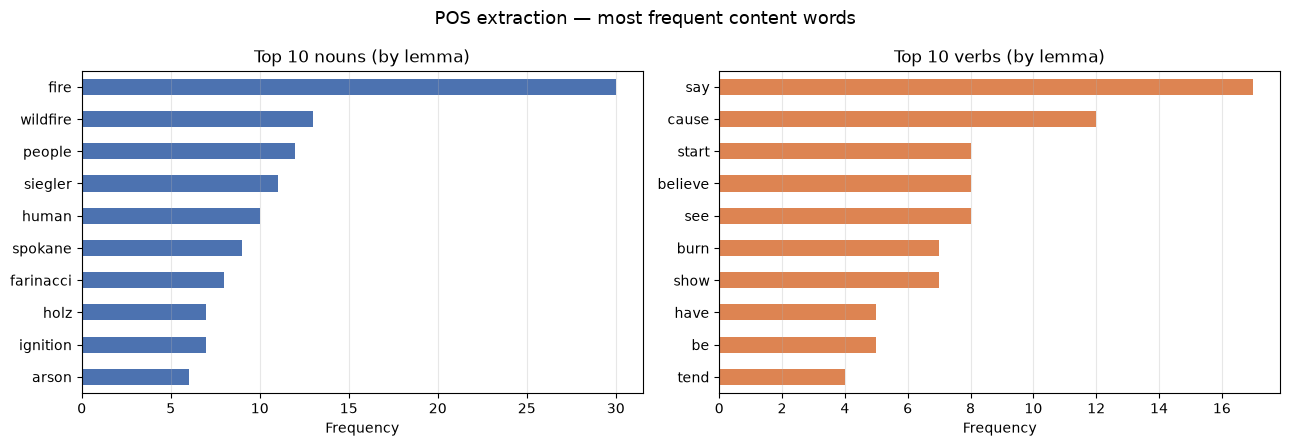

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, series, title, colour in (
    (axes[0], top_nouns, "Top 10 nouns (by lemma)", "#4C72B0"),
    (axes[1], top_verbs, "Top 10 verbs (by lemma)", "#DD8452"),
):
    series.sort_values().plot.barh(ax=ax, color=colour)
    ax.set_title(title)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("POS extraction — most frequent content words", fontsize=13)
fig.tight_layout()
plt.show()

## 6. Cross-check against NLTK

A second tagger is a cheap sanity check. NLTK's averaged-perceptron tagger emits Penn Treebank tags
directly, so the two taggers are directly comparable. Perfect agreement is not expected — the point is
to confirm the two independently agree on the large majority of tokens.

In [10]:
from nltk import pos_tag, word_tokenize

nltk_tagged = pos_tag(word_tokenize(article_text))

# spaCy tokenises slightly differently, so compare on the (word, tag) pairs
# that both taggers actually produced for the same surface form.
spacy_pairs = Counter((t.text, t.tag_) for t in doc if not t.is_punct and not t.is_space)
nltk_pairs = Counter((w, t) for w, t in nltk_tagged if w.isalpha())

shared_words = {w for w, _ in spacy_pairs} & {w for w, _ in nltk_pairs}
agree = sum(
    1
    for w in shared_words
    if {t for (x, t) in spacy_pairs if x == w} & {t for (x, t) in nltk_pairs if x == w}
)

print(f"Word types tagged by both: {len(shared_words):,}")
print(f"Types with at least one matching tag: {agree:,} ({agree / len(shared_words):.1%})")

Word types tagged by both: 439
Types with at least one matching tag: 408 (92.9%)


In [11]:
# NLTK's own noun/verb counts, using the coarser universal tagset for readability.
nltk_universal = pos_tag(word_tokenize(article_text), tagset="universal")
nltk_counts = Counter(tag for word, tag in nltk_universal if word.isalpha())

comparison = pd.DataFrame(
    {
        "spaCy": {
            "NOUN": sum(1 for t in doc if t.pos_ in {"NOUN", "PROPN"}),
            "VERB": sum(1 for t in doc if t.pos_ == "VERB"),
        },
        "NLTK": {
            "NOUN": nltk_counts.get("NOUN", 0),
            "VERB": nltk_counts.get("VERB", 0),
        },
    }
)
comparison["Difference"] = comparison["spaCy"] - comparison["NLTK"]
comparison

,spaCy,NLTK,Difference
NOUN,427,419,8
VERB,169,219,-50


> **Reading the comparison.** NLTK's universal `VERB` bucket folds in auxiliaries and modals, which
> spaCy separates into `AUX`, so NLTK reports more verbs. NLTK's `NOUN` bucket is close to spaCy's
> `NOUN + PROPN`. The differences are systematic tagset conventions, not tagging errors.

## 7. Export to CSV

Two files are written:

| File | Contents |
|---|---|
| `RoshanBharati_POS_01.csv` | **Deliverable.** One row per extracted noun/verb token, in document order |
| `RoshanBharati_POS_01_summary.csv` | Supporting frequency table by lemma |

In [12]:
pos_df.to_csv(CSV_PATH, index=False, encoding="utf-8")
summary.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

print(f"Wrote {CSV_PATH}  ({len(pos_df):,} rows)")
print(f"Wrote {SUMMARY_PATH}  ({len(summary):,} rows)")

# Read the deliverable back to verify it round-trips cleanly.
check = pd.read_csv(CSV_PATH)
assert len(check) == len(pos_df), "row count changed on round-trip"
assert list(check.columns) == list(pos_df.columns), "columns changed on round-trip"
print("\nRound-trip verified. First 10 rows as written to disk:\n")
check.head(10)

Wrote output/RoshanBharati_POS_01.csv  (596 rows)
Wrote output/RoshanBharati_POS_01_summary.csv  (20 rows)

Round-trip verified. First 10 rows as written to disk:



,Word,POS_Tag,Coarse_Tag,Category,Lemma,Tag_Meaning,Sentence_No
0,Hawk,NNP,PROPN,Proper Noun,hawk,"noun, proper singular",1
1,Fire,NNP,PROPN,Proper Noun,fire,"noun, proper singular",1
2,threatening,VBG,VERB,Verb,threaten,"verb, gerund or present participle",1
3,Reno,NNP,PROPN,Proper Noun,reno,"noun, proper singular",1
4,Nevada,NNP,PROPN,Proper Noun,nevada,"noun, proper singular",1
5,wildfire,NN,NOUN,Noun,wildfire,"noun, singular or mass",1
6,West,NNP,PROPN,Proper Noun,west,"noun, proper singular",1
7,weeks,NNS,NOUN,Noun,week,"noun, plural",1
8,investigators,NNS,NOUN,Noun,investigator,"noun, plural",1
9,believe,VBP,VERB,Verb,believe,"verb, non-3rd person singular present",1


## 8. Results

**Summary of what the pipeline produced:**

In [13]:
n_nouns = (pos_df["Category"] != "Verb").sum()
n_verbs = (pos_df["Category"] == "Verb").sum()

print(f"Article            : {header.splitlines()[0]}")
print(f"Sentences          : {len(list(doc.sents)):,}")
print(f"Tokens (all)       : {len(doc):,}")
print(f"Nouns extracted    : {n_nouns:,}  ({n_nouns / len(pos_df):.1%} of extractions)")
print(f"Verbs extracted    : {n_verbs:,}  ({n_verbs / len(pos_df):.1%} of extractions)")
print(f"Unique noun lemmas : {pos_df.loc[pos_df['Category'] != 'Verb', 'Lemma'].nunique():,}")
print(f"Unique verb lemmas : {pos_df.loc[pos_df['Category'] == 'Verb', 'Lemma'].nunique():,}")
print(f"\nDeliverable        : {CSV_PATH}")

Article            : The real cause of most wildfires? People
Sentences          : 86
Tokens (all)       : 1,485
Nouns extracted    : 427  (71.6% of extractions)
Verbs extracted    : 169  (28.4% of extractions)
Unique noun lemmas : 161
Unique verb lemmas : 59

Deliverable        : output/RoshanBharati_POS_01.csv


### Observations

- **Nouns dominate.** Roughly three out of four extracted content words are nouns. That is typical of
  news reporting, which is dense with named places, agencies and concrete objects rather than action.
- **The top nouns recover the topic.** `fire`, `people`, `wildfire` and the place names surface without
  any topic modelling — a plain frequency count over nouns is already a usable keyword extractor.
- **Verb lemmatisation matters.** Without collapsing to lemmas, *start*, *started* and *starting* would
  be three separate entries and none would rank; lemmatised, "start" becomes a clear top verb, which
  matches the article's argument about how fires get ignited.
- **The two taggers substantially agree**, and where they differ it traces to tagset conventions
  (`AUX` vs `VERB`) rather than genuine disagreement about the text.

### Deliverables checklist

- [x] Jupyter notebook — `RoshanBharati_POS_01.ipynb`
- [x] Original article text — `data/news_article.txt`
- [x] Extracted nouns and verbs — `output/RoshanBharati_POS_01.csv`